# 01 — Exploratory Data Analysis

We want to know:

1. whether the files are clean (types, missing values, duplicates, train/test overlap),
2. how labels are distributed overall and over time, and which time steps are train vs test,
3. how the transaction graph (edge list) relates to the train and test sets,
4. whether graph degree differs between illicit and licit transactions,
5. whether the "93 local + 72 aggregated" feature split from the original Elliptic dataset holds here.

In [ ]:
import sys
from pathlib import Path

# Make `src` importable whether Jupyter was started in the repo root or in notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import (load_train, load_test, load_edges, labeled,
                      ID_COL, TIME_COL, LABEL_COL, TEST_INDEX_COL, FEATURE_COLS, SEED)

pd.set_option("display.width", 140)
np.random.seed(SEED)

# Consistent colours across all plots
C_LICIT, C_ILLICIT, C_UNKNOWN, C_TEST = "#2a78d6", "#eb6834", "#b4b2ab", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": "#898781", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})

## 1. Load the data and check basic quality

In [2]:
train = load_train()
test = load_test()
edges = load_edges()

for name, df in [("train", train), ("test", test), ("edges", edges)]:
    print(f"{name:6s} shape = {df.shape}")

train  shape = (141772, 168)
test   shape = (15329, 168)
edges  shape = (234355, 2)


In [3]:
# Column differences between train and test
print("only in train:", [c for c in train.columns if c not in test.columns])
print("only in test: ", [c for c in test.columns if c not in train.columns])

# dtypes: features should all be float, ids/time steps int
print("\ntrain dtypes:", train.dtypes.value_counts().to_dict())
print("test dtypes: ", test.dtypes.value_counts().to_dict())

only in train: ['label']
only in test:  ['index']

train dtypes: {dtype('float64'): 166, dtype('int64'): 2}
test dtypes:  {dtype('float64'): 165, dtype('int64'): 3}


In [ ]:
# Missing values (In train, a missing label means "unknown", so we check it separately)
print("missing feature values - train:", train[FEATURE_COLS].isna().sum().sum(),
      "| test:", test[FEATURE_COLS].isna().sum().sum())
print("missing labels in train (= unknown):", train[LABEL_COL].isna().sum())

# Duplicates and train/test overlap
print("\nduplicate txIds - train:", train[ID_COL].duplicated().sum(), "| test:", test[ID_COL].duplicated().sum())
print("txIds in both train and test:", len(set(train[ID_COL]) & set(test[ID_COL])))
print("duplicate edges:", edges.duplicated().sum(), "| self-loops:", (edges.txId1 == edges.txId2).sum())

missing feature values - train: 0 | test: 0
missing labels in train (= unknown): 110537

duplicate txIds - train: 0 | test: 0
txIds in both train and test: 0
duplicate edges: 0 | self-loops: 0


In [6]:
# Features are described as pre-normalised: check their scale
desc = train[FEATURE_COLS].describe().T[["mean", "std", "min", "max"]]
print(desc.describe().round(2))

         mean     std     min     max
count  165.00  165.00  165.00  165.00
mean    -0.04    0.97   -1.32   39.76
std      0.11    0.17    2.17   66.36
min     -0.53    0.27  -13.09    0.74
25%     -0.02    0.94   -1.63    2.68
50%     -0.00    1.02   -0.26   11.00
75%      0.01    1.08   -0.16   46.26
max      0.08    1.19   -0.01  289.20


## 2. Labels: overall and over time

In [ ]:
counts = train[LABEL_COL].map({0: "licit", 1: "illicit"}).fillna("unknown").value_counts()
summary = pd.DataFrame({"count": counts, "share_of_train": (counts / len(train)).round(3)})
print(summary)

lab = labeled(train)
print(f"\nAmong labeled rows: {lab[LABEL_COL].mean():.1%} illicit "
      f"(about 1 illicit for every {(1 - lab[LABEL_COL].mean()) / lab[LABEL_COL].mean():.1f} licit)")

          count  share_of_train
label                          
unknown  110537           0.780
licit     27591           0.195
illicit    3644           0.026

Among labeled rows: 11.7% illicit (about 1 illicit for every 7.6 licit)


In [8]:
# Which time steps are in train and which are in test?
print("train time steps:", train[TIME_COL].min(), "to", train[TIME_COL].max(), f"({train[TIME_COL].nunique()} steps)")
print("test time steps: ", test[TIME_COL].min(), "to", test[TIME_COL].max(), f"({test[TIME_COL].nunique()} steps)")
print("overlap in time steps:", sorted(set(train[TIME_COL]) & set(test[TIME_COL])))

train time steps: 1 to 35 (35 steps)
test time steps:  36 to 49 (14 steps)
overlap in time steps: []


In [9]:
# Per-time-step table
per_step = (train[[TIME_COL]].assign(cls=train[LABEL_COL].map({0: "licit", 1: "illicit"}).fillna("unknown"))
            .groupby(TIME_COL)["cls"].value_counts().unstack(fill_value=0)[["licit", "illicit", "unknown"]])
per_step["labeled"] = per_step.licit + per_step.illicit
per_step["illicit_rate"] = (per_step.illicit / per_step.labeled).round(3)
test_per_step = test[TIME_COL].value_counts().sort_index().rename("test_rows")
per_step

cls,licit,illicit,unknown,labeled,illicit_rate
time_step,,,,,
1,2130,17,5733,2147,0.008
2,1099,18,3427,1117,0.016
3,1268,11,5342,1279,0.009
4,1410,30,4253,1440,0.021
5,1874,8,4921,1882,0.004
6,480,5,3843,485,0.010
7,1101,102,4845,1203,0.085
8,1098,67,3292,1165,0.058
9,530,248,4218,778,0.319


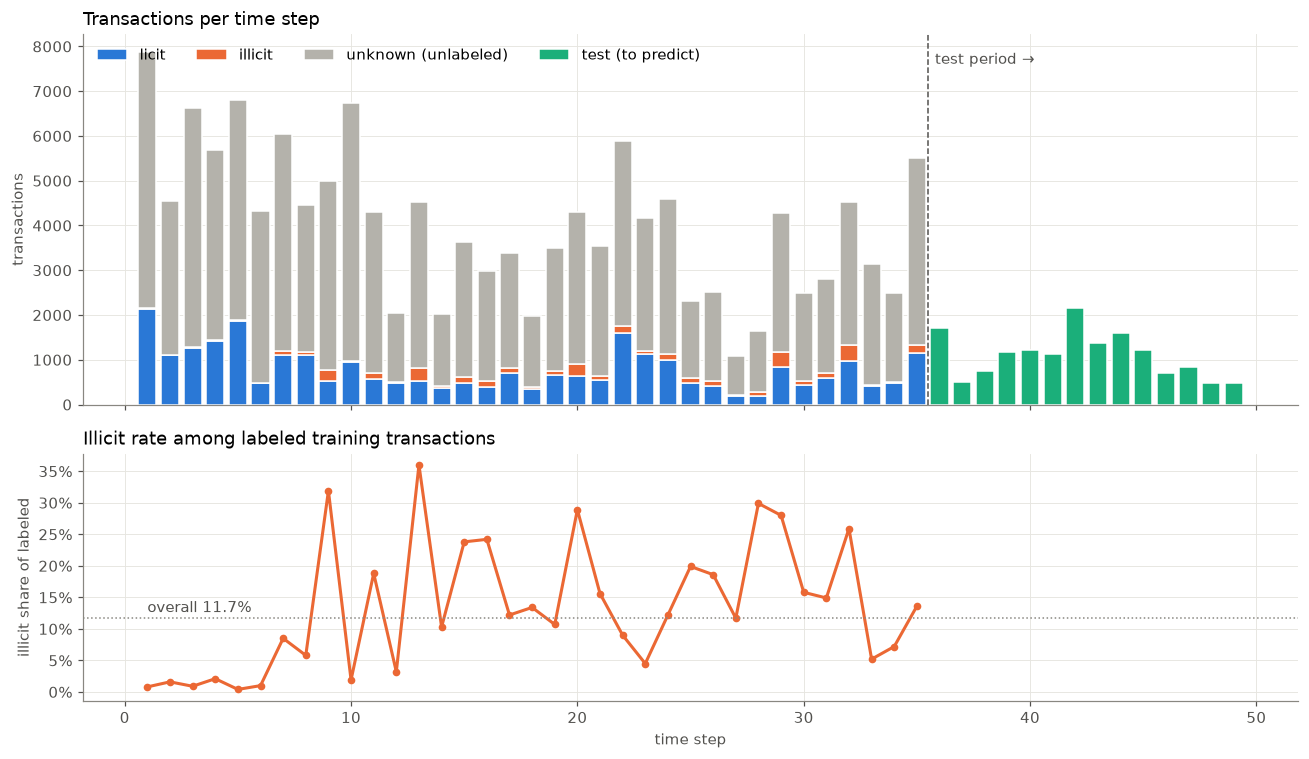

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 2]})

# Top: number of transactions per step, stacked by label (train) and test rows
ax = axes[0]
x = per_step.index
ax.bar(x, per_step.licit, color=C_LICIT, label="licit", edgecolor="white", linewidth=1)
ax.bar(x, per_step.illicit, bottom=per_step.licit, color=C_ILLICIT, label="illicit", edgecolor="white", linewidth=1)
ax.bar(x, per_step.unknown, bottom=per_step.labeled, color=C_UNKNOWN, label="unknown (unlabeled)", edgecolor="white", linewidth=1)
ax.bar(test_per_step.index, test_per_step.values, color=C_TEST, label="test (to predict)", edgecolor="white", linewidth=1)
ax.axvline(35.5, color="#52514e", ls="--", lw=1)
ax.text(35.8, ax.get_ylim()[1] * 0.92, "test period →", color="#52514e")
ax.set_ylabel("transactions")
ax.set_title("Transactions per time step", loc="left")
ax.legend(ncol=4, loc="upper left")

# Bottom: illicit share among labeled rows (train only - test labels are hidden)
ax = axes[1]
ax.plot(x, per_step.illicit_rate, color=C_ILLICIT, lw=2, marker="o", ms=4)
ax.axhline(lab[LABEL_COL].mean(), color="#898781", lw=1, ls=":")
ax.text(1, lab[LABEL_COL].mean() + 0.01, f"overall {lab[LABEL_COL].mean():.1%}", color="#52514e")
ax.set_ylabel("illicit share of labeled")
ax.set_xlabel("time step")
ax.set_title("Illicit rate among labeled training transactions", loc="left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()

Most training rows are unlabeled (grey). The illicit rate among labeled rows swings a lot
between steps, which means validation AUC computed on a single step will be noisy which is one reason we will report AUC per validation step.

Note that the test bars are much shorter than the train bars, even though they cover the same kind of period.
Section 3 explains why.

## 3. The transaction graph

Each edge `txId1 → txId2` means an output of `txId1` is spent by `txId2`.

Are the nodes in the edge list found in our train and test files?

In [11]:
nodes = pd.concat([
    train[[ID_COL, TIME_COL, LABEL_COL]].assign(split="train"),
    test[[ID_COL, TIME_COL]].assign(split="test"),
], ignore_index=True)

edge_ids = set(edges.txId1) | set(edges.txId2)
known_ids = set(nodes[ID_COL])
missing_ids = edge_ids - known_ids

print("distinct transactions in edge list:", len(edge_ids))
print("transactions in train + test:      ", len(known_ids))
print("in edge list but in neither file:  ", len(missing_ids))
print("in train/test but with no edges:   ", len(known_ids - edge_ids))

distinct transactions in edge list: 203769
transactions in train + test:       157101
in edge list but in neither file:   46668
in train/test but with no edges:    0


46,668 transactions appear in the edge list but have **no row in train or test** (no features, no time step).
Let's give every node a role and see how edges connect the roles.

In [12]:
role = nodes.set_index(ID_COL)["split"].copy()
is_lab_train = (nodes["split"] == "train") & nodes[LABEL_COL].notna()
role[is_lab_train.values] = "train_labeled"
role = role.replace({"train": "train_unlabeled"})

e = edges.assign(src_role=edges.txId1.map(role).fillna("missing"),
                 dst_role=edges.txId2.map(role).fillna("missing"))
pd.crosstab(e.src_role, e.dst_role, margins=True)

dst_role,missing,test,train_labeled,train_unlabeled,All
src_role,,,,,
missing,34192,18206,0,0,52398
test,6039,12724,0,0,18763
train_labeled,0,0,23900,10535,34435
train_unlabeled,0,0,31173,97586,128759
All,40231,30930,55073,108121,234355


In [13]:
# Verify: does every edge connect two transactions from the same time step?
ts = nodes.set_index(ID_COL)[TIME_COL]
e["src_ts"] = e.txId1.map(ts)
e["dst_ts"] = e.txId2.map(ts)
both_known = e.src_ts.notna() & e.dst_ts.notna()
print("edges with both ends known:", both_known.sum())
print("  ... same time step:       ", (e.src_ts == e.dst_ts)[both_known].sum())
print("  ... different time steps: ", (e.src_ts != e.dst_ts)[both_known].sum())

# Which time steps do the "missing" nodes belong to? Infer from their known neighbours.
m = e[(e.src_role == "missing") ^ (e.dst_role == "missing")]   # exactly one end missing
neigh_ts = np.where(m.src_role == "missing", m.dst_ts, m.src_ts)
missing_with_known_neighbour = set(np.where(m.src_role == "missing", m.txId1, m.txId2))
print("\nmissing nodes with at least one known neighbour:", len(missing_with_known_neighbour))
print("time steps of those neighbours: min", int(neigh_ts.min()), "max", int(neigh_ts.max()))

edges with both ends known: 175918
  ... same time step:        175918
  ... different time steps:  0

missing nodes with at least one known neighbour: 17897
time steps of those neighbours: min 36 max 49


**What this tells us**

- Every edge whose two ends are both known stays inside a single time step.
- Train nodes only connect to train nodes; test nodes only connect to test nodes or "missing" nodes. So there is
  **no edge crossing the train/test boundary**, and graph features for a test node can never reach a training label.
- The missing nodes only ever touch test-period transactions (steps 36–49). The numbers line up exactly with the
  original Elliptic dataset (203,769 transactions, 46,564 labeled): `31,235` labeled rows in train + `15,329` test
  rows = `46,564`. So the test set appears to be **only the originally-labeled transactions** of steps 36–49, and the
  missing nodes are the **unlabeled** transactions of those steps, which were removed.

Two practical consequences:

1. Unlabeled rows in train are *not* a good stand-in for the test distribution — test rows are all "labelable"
   transactions. When we model, the labeled training rows are the right comparison group.
2. Test nodes have neighbours we cannot see (no features). Graph features must cope with that, and degree should be
   computed on the full edge list so it means the same thing in train and test (done below).

## 4. Degree distributions

Computed on the **full** edge list, so edges to missing nodes still count.

- In-degree = number of earlier transactions whose outputs this transaction spends.
- Out-degree = number of later transactions that spend this transaction's outputs.

In [14]:
in_deg = edges.txId2.value_counts()
out_deg = edges.txId1.value_counts()
nodes["in_degree"] = nodes[ID_COL].map(in_deg).fillna(0).astype(int)
nodes["out_degree"] = nodes[ID_COL].map(out_deg).fillna(0).astype(int)
nodes["degree"] = nodes.in_degree + nodes.out_degree

# Compare test against *labeled* train rows: test appears to contain only labelable transactions (section 3)
nodes["role"] = nodes[ID_COL].map(role)
nodes.groupby("role")[["in_degree", "out_degree"]].describe(percentiles=[0.5, 0.9, 0.99]).T.round(2)

role                  test  train_labeled  train_unlabeled
in_degree  count  15329.00       31235.00        110537.00
           mean       2.02           1.76             0.98
           std        8.65           6.26             2.26
           min        0.00           0.00             0.00
           50%        1.00           1.00             1.00
           90%        2.00           2.00             1.00
           99%       42.00          22.00             5.00
           max      241.00         284.00           212.00
out_degree count  15329.00       31235.00        110537.00
           mean       1.22           1.10             1.16
           std        1.79           3.56             1.16
           min        0.00           0.00             0.00
           50%        1.00           1.00             1.00
           90%        2.00           2.00             2.00
           99%        9.00           5.00             5.00
           max       99.00         472.00            95.00

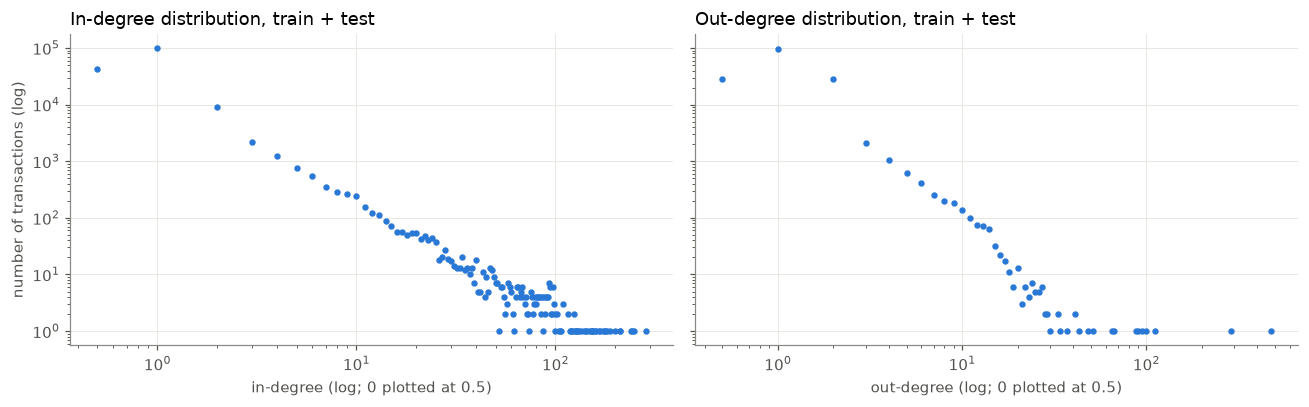

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, col in zip(axes, ["in_degree", "out_degree"]):
    vc = nodes[col].value_counts().sort_index()
    ax.scatter(np.maximum(vc.index.values, 0.5), vc.values, s=10, color=C_LICIT)  # 0 shown at x=0.5 on log scale
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(f"{col.replace('_', '-')} (log; 0 plotted at 0.5)")
    ax.set_title(f"{col.replace('_', '-').capitalize()} distribution, train + test", loc="left")
axes[0].set_ylabel("number of transactions (log)")
plt.tight_layout(); plt.show()

Both distributions are heavy-tailed: most transactions have 0–2 edges, a few have hundreds (e.g. exchanges sweeping
many deposits). Now compare illicit vs licit (labeled training rows only).

In [16]:
lab_nodes = nodes[(nodes.split == "train") & nodes[LABEL_COL].notna()].copy()
lab_nodes["cls"] = lab_nodes[LABEL_COL].map({0: "licit", 1: "illicit"})

def degree_profile(g):
    return pd.Series({
        "n": len(g),
        "mean in": g.in_degree.mean(), "median in": g.in_degree.median(), "share in=0": (g.in_degree == 0).mean(),
        "mean out": g.out_degree.mean(), "median out": g.out_degree.median(), "share out=0": (g.out_degree == 0).mean(),
        "share in=1 & out=1": ((g.in_degree == 1) & (g.out_degree == 1)).mean(),
        "share degree>=10": (g.degree >= 10).mean(),
    })

lab_nodes.groupby("cls").apply(degree_profile, include_groups=False).T.round(3)

cls,illicit,licit
n,3644.000,27591.000
mean in,1.254,1.830
median in,1.000,1.000
share in=0,0.256,0.318
mean out,0.755,1.148
median out,1.000,1.000
share out=0,0.307,0.261
share in=1 & out=1,0.383,0.201
share degree>=10,0.005,0.042


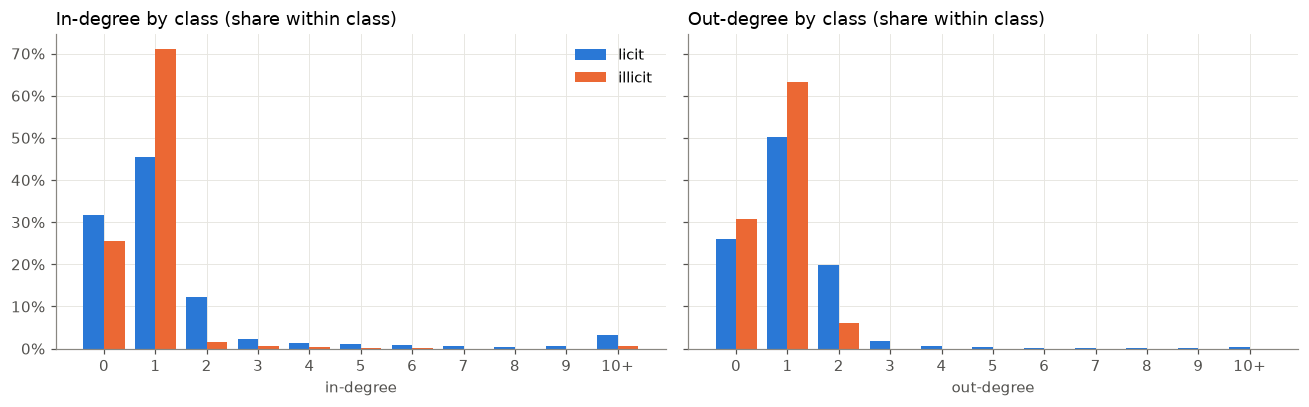

In [17]:
# Distribution of in/out degree per class, capped at 10 for readability ("10" = 10 or more)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, col in zip(axes, ["in_degree", "out_degree"]):
    capped = lab_nodes[col].clip(upper=10)
    share = (pd.crosstab(capped, lab_nodes.cls, normalize="columns"))[["licit", "illicit"]]
    w = 0.4
    ax.bar(share.index - w / 2, share.licit, width=w, color=C_LICIT, label="licit")
    ax.bar(share.index + w / 2, share.illicit, width=w, color=C_ILLICIT, label="illicit")
    ax.set_xticks(range(0, 11)); ax.set_xticklabels([str(i) for i in range(10)] + ["10+"])
    ax.set_xlabel(col.replace("_", "-"))
    ax.set_title(f"{col.replace('_', '-').capitalize()} by class (share within class)", loc="left")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend()
plt.tight_layout(); plt.show()

**Reading the degree results**

- The labeled training rows and the test rows have similar degree profiles, and both are quite different from the
  unlabeled rows (e.g. 99th-percentile in-degree: 22 for labeled train and 42 for test, but only 5 for unlabeled).
  This is more evidence that the test set is made of originally-labeled transactions.
- **Illicit transactions look like links in a chain.** 71% of illicit rows have in-degree exactly 1 (licit: 46%),
  and 38% have exactly one edge in and one edge out (licit: 20%). This fits "peeling chains", where funds pass
  through a long sequence of simple one-in / one-out transactions.
- **Hubs are almost always licit.** 4.2% of licit rows have degree ≥ 10, against 0.5% of illicit rows. These hubs
  are likely exchanges or payout services.
- So degree is informative, but it is only a weak signal because the bulk of both classes sits at degree 0–2.

## 5. Does the local / aggregated feature split hold?

In the original Elliptic data, the first 93 features describe the transaction itself and the last 72 are
aggregates over its one-hop neighbours. The columns here are anonymised, so we check this from the data.

**Check 1 — correlation structure.** If the two groups are different kinds of information, features should
correlate more strongly *within* a group than *across* groups. The heatmap shows correlation between all 165
features (labeled + unlabeled training rows), with the hypothesised boundary drawn after feature 93.

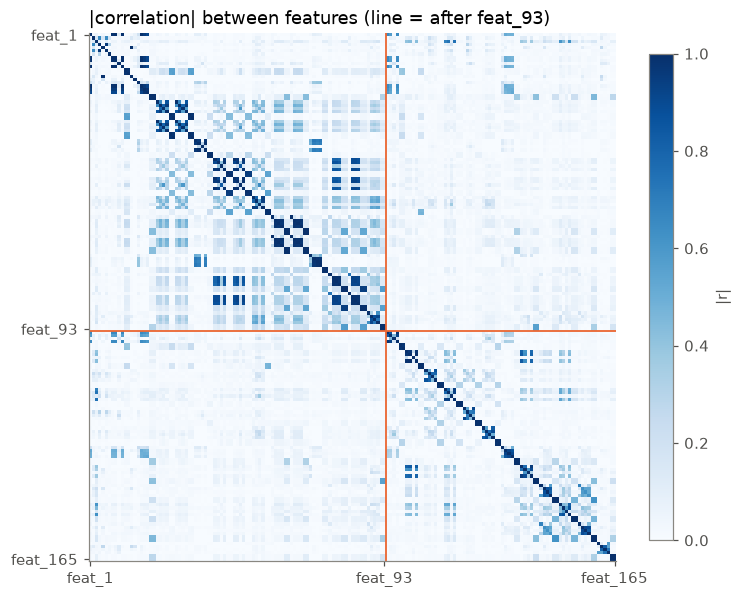

In [18]:
corr = train[FEATURE_COLS].corr().abs()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="Blues", vmin=0, vmax=1)
for b in [92.5]:
    ax.axvline(b, color=C_ILLICIT, lw=1.2); ax.axhline(b, color=C_ILLICIT, lw=1.2)
ticks = [0, 92, 164]
ax.set_xticks(ticks); ax.set_xticklabels(["feat_1", "feat_93", "feat_165"])
ax.set_yticks(ticks); ax.set_yticklabels(["feat_1", "feat_93", "feat_165"])
ax.grid(False)
ax.set_title("|correlation| between features (line = after feat_93)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.8, label="|r|")
plt.tight_layout(); plt.show()

**Check 2 — where is the best boundary?** For every possible split point *k*, compute the mean |correlation|
*across* the two groups (features 1..k vs k+1..165). The split that best separates two blocks has the lowest
cross-group correlation relative to within-group correlation.

best split: after feat_99  (cross/within = 0.315)
    cross  within  ratio
k                       
88  0.040   0.097  0.413
90  0.037   0.099  0.379
92  0.035   0.101  0.346
93  0.034   0.102  0.334
94  0.034   0.102  0.333
96  0.033   0.102  0.329
98  0.033   0.102  0.319


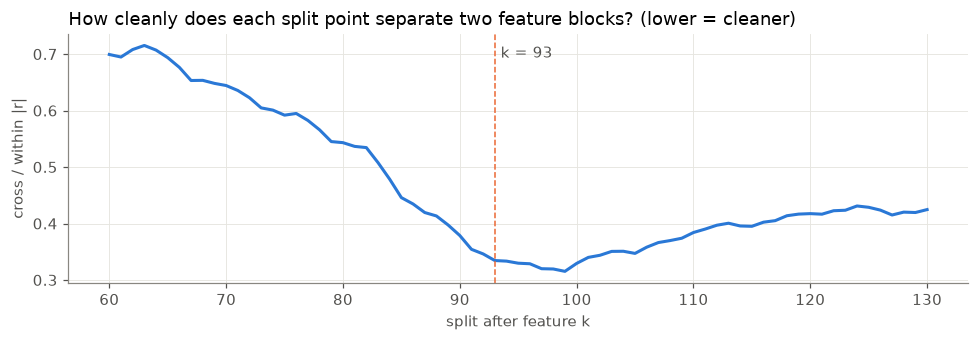

In [19]:
C = corr.values.copy()
np.fill_diagonal(C, np.nan)

rows = []
for k in range(60, 131):
    within = np.nanmean(np.concatenate([C[:k, :k].ravel(), C[k:, k:].ravel()]))
    cross = np.nanmean(C[:k, k:])
    rows.append({"k": k, "cross": cross, "within": within, "ratio": cross / within})
scan = pd.DataFrame(rows)
best = scan.loc[scan.ratio.idxmin()]
print(f"best split: after feat_{int(best.k)}  (cross/within = {best.ratio:.3f})")
print(scan.set_index("k").loc[[88, 90, 92, 93, 94, 96, 98]].round(3))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(scan.k, scan.ratio, color=C_LICIT, lw=2)
ax.axvline(93, color=C_ILLICIT, ls="--", lw=1)
ax.text(93.5, scan.ratio.max() * 0.97, "k = 93", color="#52514e")
ax.set_xlabel("split after feature k"); ax.set_ylabel("cross / within |r|")
ax.set_title("How cleanly does each split point separate two feature blocks? (lower = cleaner)", loc="left")
plt.tight_layout(); plt.show()

**Check 3 — can the last 72 features be rebuilt from neighbours?** If they are neighbour aggregates, a regression
on simple aggregates (mean / max / min / std) of the neighbours' first 93 features should explain them well.
We use training steps only, where every neighbour is known.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

X = train.set_index(ID_COL)[FEATURE_COLS]
local = X[FEATURE_COLS[:93]]

# Undirected neighbour list restricted to training nodes
und = pd.concat([edges.set_axis(["a", "b"], axis=1), edges[["txId2", "txId1"]].set_axis(["a", "b"], axis=1)])
und = und[und.a.isin(X.index) & und.b.isin(X.index)]
g = local.loc[und.b.values].set_axis(und.a.values).groupby(level=0)
neigh_agg = pd.concat([g.mean().add_suffix("_mean"), g.max().add_suffix("_max"),
                       g.min().add_suffix("_min"), g.std().fillna(0).add_suffix("_std")], axis=1)

A = neigh_agg.values
Y = X.loc[neigh_agg.index]
i_fit, i_eval = train_test_split(np.arange(len(A)), test_size=0.3, ra1ndom_state=SEED)

r2 = {}
for c in FEATURE_COLS:
    y = Y[c].values
    pred = Ridge(alpha=1.0).fit(A[i_fit], y[i_fit]).predict(A[i_eval])
    r2[c] = 1 - ((y[i_eval] - pred) ** 2).sum() / ((y[i_eval] - y[i_eval].mean()) ** 2).sum()
r2 = pd.Series(r2)
print("median R^2 from neighbour aggregates:")
print("  feat_1..93:  ", round(r2.iloc[:93].median(), 3))
print("  feat_94..165:", round(r2.iloc[93:].median(), 3))

median R^2 from neighbour aggregates:
  feat_1..93:   0.177
  feat_94..165: 0.103


**Verdict on the feature split**

- The heatmap shows two blocks: features inside each group correlate with one another, and correlation *across*
  the line after `feat_93` is low (average |r| about 0.03 across groups vs about 0.10 within). That fits two different
  kinds of information.
- The scan does **not** pin the boundary to exactly 93. The curve keeps falling a little to a shallow minimum at
  k = 99 (ratio 0.315 vs 0.334 at k = 93). Anywhere in about 93–99 separates the blocks almost equally well.
- Simple neighbour aggregates explain the last 72 columns *worse* than the first 93 (median R² 0.10 vs 0.18).
  So we cannot reproduce the "aggregated" features from the data we have. In the original data they were
  probably computed from unnormalised values, or over neighbours we can't see.

**Conclusion:** the 93 / 72 split is *broadly consistent* with the data but not strictly confirmed. We keep it as a
working assumption (`LOCAL_FEATURE_COLS` / `AGG_FEATURE_COLS` in `src/data.py`) and avoid depending on the exact
boundary in anything important.

## Key findings

**Data quality**
1. The files are clean: no missing feature values, no duplicate transactions or edges, no self-loops, and no
   transaction appears in both train and test. All 165 features are already roughly standardised (mean ≈ 0, sd ≈ 1).
2. Column names are `feat_1 … feat_165` (not `feature_*`). `test.csv` has an extra `index` column (0 … 15,328);
   this is the row id the submission uses.

**Labels and time**
3. Train has 141,772 transactions over time steps 1–35. Only 22% are labeled: 27,591 licit and 3,644 illicit
   (**11.7% of labeled rows are illicit**). The other 78% are unknown.
4. Test has 15,329 transactions over steps 36–49, so it is entirely in the future of train. Validation must
   therefore be temporal.
5. The illicit rate changes a lot from step to step, from about 0.4–2% (steps 1–6) to 36% (step 13). A model will see
   different class balances in different periods, and validation AUC on any single step will be noisy.

**The graph**
6. Every edge connects two transactions in the **same time step** (verified for all 175,918 edges with both ends
   known). No edge crosses between train and test.
7. **46,668 transactions appear in the edge list but in neither file.** They belong to the test period (steps 36–49).
   The counts match the original Elliptic dataset exactly: 31,235 labeled train + 15,329 test = 46,564 =
   all labeled Elliptic transactions. So **the test set appears to be the originally-labeled transactions of steps
   36–49**, and the hidden nodes are that period's unlabeled transactions. Degree profiles agree: test rows look
   like labeled train rows, not unlabeled ones.
   - *Implication:* unlabeled training rows are not a good proxy for the test population.
   - *Implication:* graph features for test nodes must cope with neighbours that have no features. Degree should be
     counted on the full edge list so it means the same thing in train and test.

**Degree**
8. Most transactions have in- and out-degree of 0–2. A small number of hubs have hundreds of edges.
9. Illicit transactions are much more often simple one-in / one-out links (38% vs 20% licit), and very rarely hubs
   (0.5% vs 4.2% licit with degree ≥ 10). This looks like peeling chains. Degree carries some signal and is worth
   adding as a feature later.

**Features**
10. The "first 93 local / last 72 aggregated" split is broadly supported by the correlation structure but not exactly
    confirmed (the best boundary lies anywhere from 93 to 99). We keep it as a working assumption.